# Asset Pricing Architectures — CAPM, APT, and Risk-Adjusted Performance

**Market chosen:** USA (NYSE example)  
**Frequency:** Monthly (resampled from daily)  
**Window:** 5 years (60 monthly observations of returns)

This notebook is designed to be **production-ready**: it downloads data, cleans/aligned it, runs regressions, generates diagnostics tables, constructs the required portfolio, computes performance ratios, and produces the CML/SML charts.

## Data specification (what the notebook uses)
- **4 equities** (different sectors): adjusted close prices (monthly)
- **Market portfolio proxy (Rm):** NYSE Composite (default: `^NYA`) adjusted close prices (monthly)
- **Risk-free rate (Rf):** 3-month / 91-day Treasury Bill yield (FRED `TB3MS`, monthly, % annualized)
- **APT macro factors (2):** CPI level (FRED `CPIAUCSL`) and Fed Funds rate (FRED `FEDFUNDS`)

 Replacement tickers/series IDs in the configuration cell below Is Possible if one decides to use a different market index or macro factor choices.

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
import requests
from io import StringIO
from scipy.linalg import null_space

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 80)

# Notebook is in /notebooks; keep outputs relative to repo root.
REPO_ROOT = Path("..").resolve()
OUTPUT_DIR = (REPO_ROOT / "outputs").resolve()
RAW_DIR = (REPO_ROOT / "data" / "raw").resolve()
PROCESSED_DIR = (REPO_ROOT / "data" / "processed").resolve()
REPORT_DIR = (REPO_ROOT / "report").resolve()

for d in (OUTPUT_DIR, RAW_DIR, PROCESSED_DIR, REPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Outputs:", OUTPUT_DIR)

Repo root: D:\NSE-Asset
Outputs: D:\NSE-Asset\outputs


In [3]:
# ---------------------------
# CONFIGURATION (EDIT HERE)
# ---------------------------

# If True, the notebook will read cached CSVs from data/raw/ when present.
# Set FORCE_REFRESH=True to re-download.
USE_CACHE = True
FORCE_REFRESH = False

# 4 equities from different sectors (example set). Replace if desired.
ASSETS = {
    "AAPL": "Technology",
    "JPM": "Financials",
    "XOM": "Energy",
    "PG": "Consumer Staples",
}

# Market proxy portfolio (Rm) — choose one:
MARKET_TICKER = "^NYA"    # NYSE Composite
# MARKET_TICKER = "^GSPC"  # S&P 500 (alternative)

# Risk-free: 3-Month Treasury Bill (monthly, annualized %)
RF_SERIES_FRED = "TB3MS"

# APT macro factors (monthly):
FACTOR_1_FRED = "CPIAUCSL"   # CPI level
FACTOR_2_FRED = "FEDFUNDS"   # Fed funds rate (%)

# Analysis window: 5 years of MONTHLY returns (60 points).
N_MONTHS = 60

# Download buffer so returns have enough history; we later keep last N_MONTHS.
END_DATE = pd.Timestamp.today().normalize()
START_DATE = (END_DATE - pd.DateOffset(years=6)).strftime("%Y-%m-%d")
END_DATE = END_DATE.strftime("%Y-%m-%d")

# Portfolio weights (given in the assignment).
WEIGHTS = pd.Series({
    "AAPL": 0.30,
    "JPM": 0.25,
    "XOM": 0.20,
    "PG": 0.25,
})

assert set(WEIGHTS.index) == set(ASSETS.keys())
assert abs(WEIGHTS.sum() - 1.0) < 1e-9

print("Assets:", list(ASSETS.keys()))
print("Market:", MARKET_TICKER)
print("Window (download):", START_DATE, "to", END_DATE)
print("USE_CACHE:", USE_CACHE, "FORCE_REFRESH:", FORCE_REFRESH)

Assets: ['AAPL', 'JPM', 'XOM', 'PG']
Market: ^NYA
Window (download): 2020-05-19 to 2026-05-19
USE_CACHE: True FORCE_REFRESH: False


In [4]:
def download_adj_close_yahoo(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    raw = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        actions=False,
        progress=False,
        group_by="column",
        threads=True,
    )
    if raw is None or raw.empty:
        raise RuntimeError("Yahoo Finance download returned empty data. Check connectivity and tickers.")

    # Prefer Adj Close; fall back to Close for instruments without adjusted series.
    if isinstance(raw.columns, pd.MultiIndex):
        level0 = raw.columns.get_level_values(0)
        if "Adj Close" in level0:
            prices = raw["Adj Close"]
        else:
            prices = raw["Close"]
    else:
        prices = raw["Adj Close"] if "Adj Close" in raw.columns else raw["Close"]

    prices = pd.DataFrame(prices).sort_index()
    prices = prices.dropna(how="all")

    # Ensure expected columns exist even if Yahoo returns a Series
    missing = [t for t in tickers if t not in prices.columns]
    if missing:
        raise RuntimeError(f"Missing tickers in Yahoo output: {missing}. Try different tickers or rerun later.")
    return prices


def _safe_filename(text: str) -> str:
    return "".join(ch if (ch.isalnum() or ch in "-_") else "_" for ch in text)


asset_tickers = list(ASSETS.keys())
all_tickers = asset_tickers + [MARKET_TICKER]

cache_key = _safe_filename("__".join(all_tickers))
prices_cache = RAW_DIR / f"yahoo_adj_close_daily__{cache_key}.csv"

if USE_CACHE and prices_cache.exists() and not FORCE_REFRESH:
    prices_daily = pd.read_csv(prices_cache, index_col=0, parse_dates=True)
else:
    prices_daily = download_adj_close_yahoo(all_tickers, START_DATE, END_DATE)
    prices_daily.to_csv(prices_cache)
    print("Saved:", prices_cache)

prices_assets_daily = prices_daily[asset_tickers]
prices_mkt_daily = prices_daily[[MARKET_TICKER]].rename(columns={MARKET_TICKER: "MKT"})

display(prices_assets_daily.tail())
display(prices_mkt_daily.tail())

Saved: D:\NSE-Asset\data\raw\yahoo_adj_close_daily__AAPL__JPM__XOM__PG___NYA.csv


Ticker,AAPL,JPM,XOM,PG
Date,,,,
2026-05-12,294.799988,304.880005,149.614502,143.910004
2026-05-13,298.869995,300.250000,150.548172,142.240005
2026-05-14,298.209991,299.910004,151.750000,142.710007
2026-05-15,300.230011,297.809998,157.919998,141.570007
2026-05-18,297.839996,300.730011,160.490005,142.389999


Ticker,MKT
Date,
2026-05-12,23015.339844
2026-05-13,22973.550781
2026-05-14,23101.849609
2026-05-15,22799.429688
2026-05-18,22900.570312


In [6]:
def download_fred_series(series_id: str, start: str, end: str) -> pd.Series:
    cache_path = RAW_DIR / f"fred__{series_id}.csv"
    if USE_CACHE and cache_path.exists() and not FORCE_REFRESH:
        tmp = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        if series_id not in tmp.columns:
            raise RuntimeError(f"Cached FRED file {cache_path} is missing column {series_id}.")
        s = tmp[series_id]
    else:
        url = "https://fred.stlouisfed.org/graph/fredgraph.csv"
        params = {"id": series_id, "cosd": start, "coed": end}
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        tmp = pd.read_csv(StringIO(resp.text))
        if tmp.empty:
            raise RuntimeError(f"Unexpected empty FRED response for {series_id}.")
        date_col = ("DATE" if "DATE" in tmp.columns else ("observation_date" if "observation_date" in tmp.columns else tmp.columns[0]))
        value_col = (series_id if series_id in tmp.columns else (tmp.columns[1] if len(tmp.columns) >= 2 else series_id))
        if value_col not in tmp.columns:
            raise RuntimeError(f"Unexpected FRED response columns for {series_id}: {list(tmp.columns)}")
        tmp[date_col] = pd.to_datetime(tmp[date_col], errors="coerce")
        tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
        tmp = tmp.dropna(subset=[date_col]).set_index(date_col).sort_index()
        tmp = tmp.rename(columns={value_col: series_id})
        tmp.to_csv(cache_path)
        print("Saved:", cache_path)
        s = tmp[series_id]
    return s.sort_index()


# Resample DAILY -> MONTHLY using last available observation (reduces microstructure noise).
prices_assets_m = prices_assets_daily.resample("ME").last()
prices_mkt_m = prices_mkt_daily.resample("ME").last()

# Log monthly returns: r_t = ln(P_t / P_{t-1})
r_assets = np.log(prices_assets_m / prices_assets_m.shift(1))
r_mkt = np.log(prices_mkt_m["MKT"] / prices_mkt_m["MKT"].shift(1)).rename("MKT")

# Risk-free (Rf): FRED series is annualized percent (monthly, %)
rf_annual_pct = download_fred_series(RF_SERIES_FRED, START_DATE, END_DATE).resample("ME").last().ffill()
rf_annual_rate = (rf_annual_pct / 100.0).rename("RF_annual")
rf_monthly_simple = ((1 + rf_annual_rate) ** (1 / 12) - 1).rename("RF_simple")
rf_monthly_log = np.log1p(rf_monthly_simple).rename("RF")

# APT macro factors (FRED, monthly)
cpi_level = download_fred_series(FACTOR_1_FRED, START_DATE, END_DATE).resample("ME").last().ffill().rename("CPI")
fedfunds = download_fred_series(FACTOR_2_FRED, START_DATE, END_DATE).resample("ME").last().ffill().rename("FEDFUNDS")

# Convert macro levels -> monthly change/growth forms
F1 = (cpi_level.pct_change() * 100.0).rename("Inflation_MoM_%")
F2 = fedfunds.diff().rename("FedFunds_Δ_pp")

# Align all series and drop missing
df = pd.concat([r_assets, r_mkt, rf_monthly_log, rf_monthly_simple, rf_annual_rate, F1, F2], axis=1).dropna()

# Keep only the last N_MONTHS (5 years) of monthly observations
df = df.tail(N_MONTHS)

# Split back out for modeling
r_assets = df[asset_tickers]
r_mkt = df["MKT"]
rf_monthly_log = df["RF"]
rf_monthly_simple = df["RF_simple"]
rf_annual_rate = df["RF_annual"]
factors_raw = df[["Inflation_MoM_%", "FedFunds_Δ_pp"]]

avg_rf_annual = float(rf_annual_rate.mean())
print("Monthly observations:", len(df))
print(f"Average annualized risk-free rate over window (mean TB3MS): {avg_rf_annual:.2%}")

# Persist the exact dataset used in the models
df.to_csv(PROCESSED_DIR / "monthly_model_dataset.csv")
prices_assets_m.to_csv(PROCESSED_DIR / "asset_prices_monthly.csv")
prices_mkt_m.to_csv(PROCESSED_DIR / "market_price_monthly.csv")
r_assets.to_csv(PROCESSED_DIR / "asset_returns_log_monthly.csv")
r_mkt.to_frame().to_csv(PROCESSED_DIR / "market_returns_log_monthly.csv")

display(df.head())

Saved: D:\NSE-Asset\data\raw\fred__TB3MS.csv
Saved: D:\NSE-Asset\data\raw\fred__CPIAUCSL.csv
Saved: D:\NSE-Asset\data\raw\fred__FEDFUNDS.csv
Monthly observations: 60
Average annualized risk-free rate over window (mean TB3MS): 3.47%


,AAPL,JPM,XOM,PG,MKT,RF,RF_simple,RF_annual,Inflation_MoM_%,FedFunds_Δ_pp
2021-05-31,-0.051817,0.065611,0.034012,0.010661,0.020524,0.000017,0.000017,0.0002,0.663506,-0.01
2021-06-30,0.094500,-0.054426,0.077602,0.000593,-0.000019,0.000033,0.000033,0.0004,0.846179,0.02
2021-07-31,0.062958,-0.018725,-0.091402,0.058959,0.002831,0.000042,0.000042,0.0005,0.461475,0.02
2021-08-31,0.041611,0.052430,-0.039412,0.001124,0.012222,0.000042,0.000042,0.0005,0.284293,-0.01
2021-09-30,-0.070462,0.023113,0.075914,-0.018357,-0.040157,0.000033,0.000033,0.0004,0.452552,-0.01


# QUESTION ONE — Empirical CAPM Implementation & Regression Diagnostics
We run OLS regressions for each asset using the CAPM excess return structure:

$$ (R_{j,t} - R_{f,t}) = \alpha_j + \beta_j (R_{m,t} - R_{f,t}) + \epsilon_{j,t}. $$

Where returns are **monthly log returns** and $R_{f,t}$ is the monthly log return implied by the 3‑month (91‑day) T‑bill yield (`TB3MS`).

In [7]:
def run_capm(excess_asset: pd.Series, excess_mkt: pd.Series) -> sm.regression.linear_model.RegressionResultsWrapper:
    X = sm.add_constant(excess_mkt.rename("MKT_EXCESS"), has_constant="add")
    return sm.OLS(excess_asset, X).fit()


# Excess returns
excess_assets = r_assets.sub(rf_monthly_log, axis=0)
excess_mkt = (r_mkt - rf_monthly_log).rename("MKT_EXCESS")

capm_models: dict[str, sm.regression.linear_model.RegressionResultsWrapper] = {
    t: run_capm(excess_assets[t], excess_mkt) for t in asset_tickers
}


def classify_beta(beta: float) -> str:
    if abs(beta) < 0.1:
        return "Risk-Free (β≈0)"
    if beta > 1.0:
        return "Aggressive (β>1)"
    if beta < 1.0:
        return "Defensive (β<1)"
    return "Market-like (β≈1)"


rows = []
for t, model in capm_models.items():
    rows.append(
        {
            "Asset": t,
            "Sector": ASSETS[t],
            "Alpha": model.params.get("const", np.nan),
            "Beta": model.params.get("MKT_EXCESS", np.nan),
            "R2": model.rsquared,
            "SE_Alpha": model.bse.get("const", np.nan),
            "SE_Beta": model.bse.get("MKT_EXCESS", np.nan),
            "t_Alpha": model.tvalues.get("const", np.nan),
            "t_Beta": model.tvalues.get("MKT_EXCESS", np.nan),
            "p_Alpha": model.pvalues.get("const", np.nan),
            "p_Beta": model.pvalues.get("MKT_EXCESS", np.nan),
        }
    )

capm_tbl = pd.DataFrame(rows).set_index("Asset").sort_index()
capm_tbl["Beta Class"] = capm_tbl["Beta"].apply(classify_beta)
capm_tbl["Alpha Significant (5%)"] = capm_tbl["p_Alpha"] < 0.05

display(capm_tbl)

capm_tbl.to_csv(OUTPUT_DIR / "capm_summary.csv")

# Save full regression output per asset for the report appendix
for t, model in capm_models.items():
    (OUTPUT_DIR / f"capm_regression__{t}.txt").write_text(model.summary().as_text(), encoding="utf-8")

,Sector,Alpha,Beta,R2,SE_Alpha,SE_Beta,t_Alpha,t_Beta,p_Alpha,p_Beta,Beta Class,Alpha Significant (5%)
Asset,,,,,,,,,,,,
AAPL,Technology,0.007011,0.864661,0.265278,0.007754,0.188948,0.904148,4.576181,0.369657,2.546121e-05,Defensive (β<1),False
JPM,Financials,0.007303,1.235879,0.579848,0.005669,0.138137,1.288310,8.946795,0.202754,1.623288e-12,Aggressive (β>1),False
PG,Consumer Staples,-0.000986,0.614907,0.227269,0.006110,0.148881,-0.161436,4.130187,0.872311,1.177607e-04,Defensive (β<1),False
XOM,Energy,0.014931,0.633852,0.121774,0.009172,0.223512,1.627817,2.835880,0.108985,6.282534e-03,Defensive (β<1),False


## Q1.4 — Portfolio beta (analytical vs direct regression)
We form an actively managed portfolio with weights $w = (0.30, 0.25, 0.20, 0.25)$.

**Analytical (weighted-average) beta**
$$\beta_p = \sum_{i=1}^4 w_i\,\beta_i.$$

**Why the direct regression matches the weighted beta (sketch):**
If portfolio excess return is the weighted sum of constituent excess returns,
$$(R_{p,t}-R_{f,t}) = \sum_i w_i (R_{i,t}-R_{f,t}),$$
then
$$\beta_p = \frac{\mathrm{Cov}(R_p-R_f,\,R_m-R_f)}{\mathrm{Var}(R_m-R_f)} = \sum_i w_i\beta_i.$$

In [8]:
# Portfolio excess return as a weighted sum of constituent excess returns
excess_port = excess_assets.mul(WEIGHTS, axis=1).sum(axis=1).rename("PORT_EXCESS")

# Analytical beta from weighted-average of individual CAPM betas
beta_analytical = float((capm_tbl["Beta"] * WEIGHTS).sum())

# Direct regression beta for the portfolio
capm_port_model = run_capm(excess_port, excess_mkt)
beta_direct = float(capm_port_model.params["MKT_EXCESS"])
alpha_direct = float(capm_port_model.params["const"])
r2_direct = float(capm_port_model.rsquared)

beta_compare = pd.DataFrame(
    {
        "Beta_Analytical": [beta_analytical],
        "Beta_DirectRegression": [beta_direct],
        "Abs_Diff": [abs(beta_analytical - beta_direct)],
        "Alpha_Direct": [alpha_direct],
        "R2_Direct": [r2_direct],
    },
    index=["Portfolio"],
)

display(beta_compare)
beta_compare.to_csv(OUTPUT_DIR / "capm_portfolio_beta_comparison.csv")
(OUTPUT_DIR / "capm_regression__PORTFOLIO.txt").write_text(capm_port_model.summary().as_text(), encoding="utf-8")

,Beta_Analytical,Beta_DirectRegression,Abs_Diff,Alpha_Direct,R2_Direct
Portfolio,0.848865,0.848865,1.110223e-16,0.006669,0.739377


1837

## Q1.5 — Interpretation (SML, alpha, and cost of equity)
Under CAPM equilibrium, security alpha is expected to decay toward zero because persistent mispricing invites arbitrage.

- If an asset plots **above** the Security Market Line (SML), it has **positive alpha** (higher realized/expected return than implied by its beta). A financial engineer may overweight/hold it, or design a hedged trade to isolate the mispricing while controlling market exposure.
- If an asset plots **below** the SML, it has **negative alpha** (underperforms given beta). One may underweight it, short it, or pair it against a similar exposure to capture the expected convergence toward fair pricing.
- **Systematic risk (β)** affects the **cost of equity** via the CAPM required return: $$E[R_j] = R_f + \beta_j(E[R_m]-R_f).$$ Higher beta raises the required return, increasing discount rates used in valuation and increasing the hurdle rate for equity financing.

# QUESTION TWO — Multi-Factor Extraction & Arbitrage Pricing Modelling (APT)
We model excess returns using two macro factors (monthly):
- $F_1$: **Inflation** (CPI month‑over‑month % change)
- $F_2$: **Interest-rate shock** (Fed Funds rate monthly change in percentage points)

A practical regression form is:
$$ (R_{j,t}-R_{f,t}) = \alpha_j + \beta_{j,F1} F_{1,t} + \beta_{j,F2} F_{2,t} + e_{j,t}. $$

To improve comparability, we standardize factors to z‑scores before regression (mean 0, std 1).

In [9]:
# 1) Clean/normalize factors into monthly change forms (already computed) and standardize (z-scores)
factors = factors_raw.copy()
factors_z = (factors - factors.mean()) / factors.std(ddof=1)
factors_z = factors_z.rename(columns={"Inflation_MoM_%": "F1_Inflation_z", "FedFunds_Δ_pp": "F2_RateShock_z"})

display(factors_z.describe().T)


def run_apt(excess_asset: pd.Series, factor_matrix: pd.DataFrame) -> sm.regression.linear_model.RegressionResultsWrapper:
    X = sm.add_constant(factor_matrix, has_constant="add")
    return sm.OLS(excess_asset, X).fit()

apt_models: dict[str, sm.regression.linear_model.RegressionResultsWrapper] = {
    t: run_apt(excess_assets[t], factors_z) for t in asset_tickers
}

rows = []
for t, model in apt_models.items():
    rows.append(
        {
            "Asset": t,
            "Sector": ASSETS[t],
            "Alpha": model.params.get("const", np.nan),
            "Beta_F1_Inflation": model.params.get("F1_Inflation_z", np.nan),
            "Beta_F2_RateShock": model.params.get("F2_RateShock_z", np.nan),
            "R2": model.rsquared,
            "F_stat": model.fvalue,
            "p_F": model.f_pvalue,
            "p_Alpha": model.pvalues.get("const", np.nan),
            "p_F1": model.pvalues.get("F1_Inflation_z", np.nan),
            "p_F2": model.pvalues.get("F2_RateShock_z", np.nan),
        }
    )

apt_tbl = pd.DataFrame(rows).set_index("Asset").sort_index()
display(apt_tbl)
apt_tbl.to_csv(OUTPUT_DIR / "apt_summary.csv")

# Save full regression output per asset
for t, model in apt_models.items():
    (OUTPUT_DIR / f"apt_regression__{t}.txt").write_text(model.summary().as_text(), encoding="utf-8")

# Compare explanatory power vs CAPM (R2)
r2_compare = pd.DataFrame({"CAPM_R2": capm_tbl["R2"], "APT_R2": apt_tbl["R2"]})
r2_compare["Δ_R2 (APT-CAPM)"] = r2_compare["APT_R2"] - r2_compare["CAPM_R2"]
display(r2_compare)
r2_compare.to_csv(OUTPUT_DIR / "r2_capm_vs_apt.csv")

,count,mean,std,min,25%,50%,75%,max
F1_Inflation_z,60.0,1.609823e-16,1.0,-1.428898,-0.691352,-0.272589,0.342240,3.088963
F2_RateShock_z,60.0,3.885781e-17,1.0,-1.807529,-0.299160,-0.299160,0.153351,3.220367


,Sector,Alpha,Beta_F1_Inflation,Beta_F2_RateShock,R2,F_stat,p_F,p_Alpha,p_F1,p_F2
Asset,,,,,,,,,,
AAPL,Technology,0.009688,-0.004379,-0.004609,0.009493,0.273129,0.761985,0.289197,0.636150,0.618564
JPM,Financials,0.011130,-0.009894,0.002067,0.021615,0.629625,0.536456,0.206018,0.268101,0.816068
PG,Consumer Staples,0.000918,-0.008096,0.001852,0.022998,0.670870,0.515254,0.894796,0.254007,0.792984
XOM,Energy,0.016894,0.011687,0.006625,0.035631,1.053015,0.355572,0.085954,0.239355,0.503023


,CAPM_R2,APT_R2,Δ_R2 (APT-CAPM)
Asset,,,
AAPL,0.265278,0.009493,-0.255786
JPM,0.579848,0.021615,-0.558233
PG,0.227269,0.022998,-0.204271
XOM,0.121774,0.035631,-0.086142


## Q2.3 — Factor interpretation (example logic)
- A **negative inflation beta** ($\beta_{\text{Inf}}<0$) means the asset’s excess returns tend to **fall when inflation rises** (in standardized terms). A portfolio manager may treat it as **poor inflation protection**, while an asset with $\beta_{\text{Inf}}>0$ behaves more like an inflation‑sensitive exposure.
- A **positive rate‑shock beta** suggests the asset benefits (or is less harmed) when policy rates rise; a negative beta suggests rate hikes are typically bad for the asset.
- The $R^2$ comparison above shows whether the 2‑factor macro model explains more variance than CAPM’s single market factor.

Highest APT alpha asset: XOM alpha= 0.01689373514740741
Lowest  APT alpha asset: PG alpha= 0.0009178737784645442

Arbitrage weights (gross=1, self-financing):


,AAPL,JPM,XOM,PG
weight,0.037913,0.430117,0.03197,-0.5


Sum weights: 0.0
Factor exposures (target 0):


,Beta_F1_Inflation,Beta_F2_RateShock
exposure,-3.794708e-19,2.168404e-19


Portfolio APT alpha (monthly): 0.005235795648290426
Portfolio APT alpha (annualized approx): 0.06282954777948511
                            OLS Regression Results                            
Dep. Variable:             ARB_EXCESS   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.035
Method:                 Least Squares   F-statistic:                     0.000
Date:                Tue, 19 May 2026   Prob (F-statistic):               1.00
Time:                        18:55:07   Log-Likelihood:                 113.31
No. Observations:                  60   AIC:                            -220.6
Df Residuals:                      57   BIC:                            -214.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------

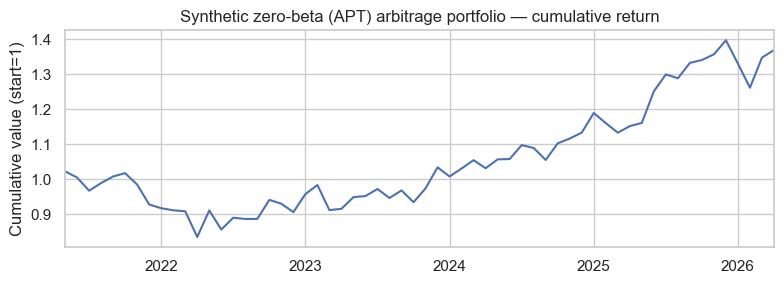

In [10]:
# Q2.4 — Synthetic zero-beta (two-factor) arbitrage portfolio
apt_betas = apt_tbl[["Beta_F1_Inflation", "Beta_F2_RateShock"]].copy()
apt_alpha = apt_tbl["Alpha"].copy()

# Identify two most "mispriced" assets by APT alpha (highest and lowest)
hi = apt_alpha.idxmax()
lo = apt_alpha.idxmin()
print("Highest APT alpha asset:", hi, "alpha=", float(apt_alpha.loc[hi]))
print("Lowest  APT alpha asset:", lo, "alpha=", float(apt_alpha.loc[lo]))

# Constraints: (1) self-financing sum(w)=0, (2) factor neutrality B' w = 0
A = np.vstack([np.ones(len(asset_tickers)), apt_betas.loc[asset_tickers].T.values])  # (3 x 4)
N = null_space(A)  # basis vectors (4 x k)

if N.size == 0:
    raise RuntimeError("No non-trivial solution for zero-beta constraints. Try different factors or assets.")

# Choose the nullspace vector that maximizes expected alpha (and then scale)
c = N.T @ apt_alpha.loc[asset_tickers].values
z = c / np.linalg.norm(c) if np.linalg.norm(c) > 0 else np.ones(N.shape[1])
w_raw = (N @ z).reshape(-1)
w = pd.Series(w_raw, index=asset_tickers)

# Flip sign so we are long the high-alpha asset (and typically short the low-alpha one)
if w.loc[hi] < 0:
    w *= -1

# Scale to unit gross exposure
w = w / w.abs().sum()

print("\nArbitrage weights (gross=1, self-financing):")
display(w.to_frame("weight").T)

# Check constraints (should be ~0 within numerical tolerance)
factor_exposure = apt_betas.loc[asset_tickers].T @ w
print("Sum weights:", float(w.sum()))
print("Factor exposures (target 0):")
display(factor_exposure.to_frame("exposure").T)

# Expected (model-implied) alpha of the arbitrage portfolio (weighted alpha)
arb_alpha = float((apt_alpha.loc[asset_tickers] * w).sum())
print("Portfolio APT alpha (monthly):", arb_alpha)
print("Portfolio APT alpha (annualized approx):", arb_alpha * 12)

# Realized excess return series (excess log returns)
arb_excess = excess_assets.mul(w, axis=1).sum(axis=1).rename("ARB_EXCESS")

# Empirical check: regress arb excess return on the two factors (betas should be near 0)
arb_model = run_apt(arb_excess, factors_z)
print(arb_model.summary())
(OUTPUT_DIR / "apt_regression__ARBITRAGE_PORTFOLIO.txt").write_text(arb_model.summary().as_text(), encoding="utf-8")

# Save weights and realized returns
w.to_csv(OUTPUT_DIR / "apt_zero_beta_arbitrage_weights.csv", header=["weight"])
arb_excess.to_frame().to_csv(OUTPUT_DIR / "apt_zero_beta_arbitrage_excess_returns.csv")

# Plot cumulative performance (in simple-return space for readability)
arb_simple = np.expm1(arb_excess)
cum = (1 + arb_simple).cumprod()
ax = cum.plot(title="Synthetic zero-beta (APT) arbitrage portfolio — cumulative return", figsize=(8, 3))
ax.set_ylabel("Cumulative value (start=1)")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "apt_arbitrage_cumulative.png")
plt.show()

## Q2.5 — Practical APT limitations (real-world quant desks)
- **Factor selection & stability:** macro factors can change relevance across regimes; relationships estimated in one period may break in another.
- **Measurement & timing:** many macro series are revised, released with lags, and can be noisy at monthly frequency.
- **Estimation error:** betas and alphas are sample estimates; small universes (few assets) make factor‑premium inference fragile.
- **Regime shifts:** crises and policy changes cause time‑varying betas and non‑linear behavior (APT’s linear assumption can fail).
- **Implementation costs:** trading to maintain factor‑neutral portfolios incurs transaction costs and shorting/financing constraints.

# QUESTION THREE — Portfolio Diagnostic Optimization & Performance Metrics
We compute annualized return/volatility, then evaluate assets and the constructed portfolio using:
- Sharpe Ratio (total risk)
- Treynor Ratio (systematic risk)
- Jensen’s Alpha (CAPM abnormal return)

We also plot:
- **CML:** Expected return vs total volatility
- **SML:** Expected return vs beta

In [11]:
# Convert log returns -> simple returns for performance metrics/plots
r_assets_simple = np.expm1(r_assets)
r_mkt_simple = np.expm1(r_mkt)
rf_simple = rf_monthly_simple.copy()

# Monthly rebalanced portfolio (simple returns)
r_port_simple = r_assets_simple.mul(WEIGHTS, axis=1).sum(axis=1).rename("PORT")


def ann_return(r_simple: pd.Series) -> float:
    return float(r_simple.mean() * 12)


def ann_vol(r_simple: pd.Series) -> float:
    return float(r_simple.std(ddof=1) * np.sqrt(12))


rf_ann = float(rf_annual_rate.mean())
rm_ann = ann_return(r_mkt_simple)
sigma_m_ann = ann_vol(r_mkt_simple)

# Betas from Q1 (CAPM)
beta_assets = capm_tbl["Beta"].copy()
beta_port = beta_direct  # from the direct portfolio regression (Q1.4)

metrics_rows = []
for t in asset_tickers:
    R = ann_return(r_assets_simple[t])
    sigma = ann_vol(r_assets_simple[t])
    beta = float(beta_assets.loc[t])
    metrics_rows.append({"Name": t, "Type": "Asset", "Sector": ASSETS[t], "R_ann": R, "Sigma_ann": sigma, "Beta": beta})

# Portfolio + Market + Risk-free point
metrics_rows.append({"Name": "PORT", "Type": "Portfolio", "Sector": "(blend)", "R_ann": ann_return(r_port_simple), "Sigma_ann": ann_vol(r_port_simple), "Beta": beta_port})
metrics_rows.append({"Name": "MKT", "Type": "Market", "Sector": MARKET_TICKER, "R_ann": rm_ann, "Sigma_ann": sigma_m_ann, "Beta": 1.0})
metrics_rows.append({"Name": "RF", "Type": "RiskFree", "Sector": RF_SERIES_FRED, "R_ann": rf_ann, "Sigma_ann": 0.0, "Beta": 0.0})

perf = pd.DataFrame(metrics_rows).set_index("Name")

# Performance ratios
perf["Sharpe"] = (perf["R_ann"] - rf_ann) / perf["Sigma_ann"].replace(0, np.nan)
perf["Treynor"] = (perf["R_ann"] - rf_ann) / perf["Beta"].replace(0, np.nan)
perf["Jensen_Alpha"] = perf["R_ann"] - (rf_ann + perf["Beta"] * (rm_ann - rf_ann))

# Rank (higher is better)
for col in ["Sharpe", "Treynor", "Jensen_Alpha"]:
    perf[f"Rank_{col}"] = perf[col].rank(ascending=False, method="dense")

display(perf.sort_index())
perf.to_csv(OUTPUT_DIR / "performance_metrics.csv")

# Also export to Excel (single file, multiple sheets)
xlsx_path = OUTPUT_DIR / "summary_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    capm_tbl.to_excel(writer, sheet_name="CAPM")
    beta_compare.to_excel(writer, sheet_name="PortfolioBeta")
    apt_tbl.to_excel(writer, sheet_name="APT")
    r2_compare.to_excel(writer, sheet_name="R2_Compare")
    perf.to_excel(writer, sheet_name="Performance")

print("Saved:", xlsx_path)

,Type,Sector,R_ann,Sigma_ann,Beta,Sharpe,Treynor,Jensen_Alpha,Rank_Sharpe,Rank_Treynor,Rank_Jensen_Alpha
Name,,,,,,,,,,,
AAPL,Asset,Technology,0.179871,0.243586,0.864661,0.595954,0.167888,0.104710,4.0,2.0,2.0
JPM,Asset,Financials,0.195826,0.236792,1.235879,0.680432,0.130370,0.103296,3.0,4.0,3.0
MKT,Market,^NYA,0.081493,0.143706,1.000000,0.325585,0.046788,0.000000,5.0,5.0,5.0
PG,Asset,Consumer Staples,0.061781,0.184723,0.614907,0.146576,0.044032,-0.001695,6.0,6.0,6.0
PORT,Portfolio,(blend),0.172948,0.143525,0.848865,0.963198,0.162856,0.098526,1.0,3.0,4.0
RF,RiskFree,TB3MS,0.034705,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,5.0
XOM,Asset,Energy,0.272923,0.268562,0.633852,0.887012,0.375826,0.208561,2.0,1.0,1.0


Saved: D:\NSE-Asset\outputs\summary_tables.xlsx


## Q3.3 — Why Treynor vs Sharpe rankings can differ
- **Sharpe** uses **total risk** ($\sigma$). It penalizes both systematic risk (market-related) and idiosyncratic risk (asset-specific).
- **Treynor** uses **systematic risk only** ($\beta$). An asset can look strong on Treynor if it has high return per unit of market risk, even if it still has large idiosyncratic volatility that Sharpe penalizes.
- Therefore, concentrated stocks (high idiosyncratic variance) often rank worse on Sharpe than on Treynor, while well-diversified portfolios typically improve on Sharpe.

Saved: D:\NSE-Asset\outputs\cml_sml_dual.png


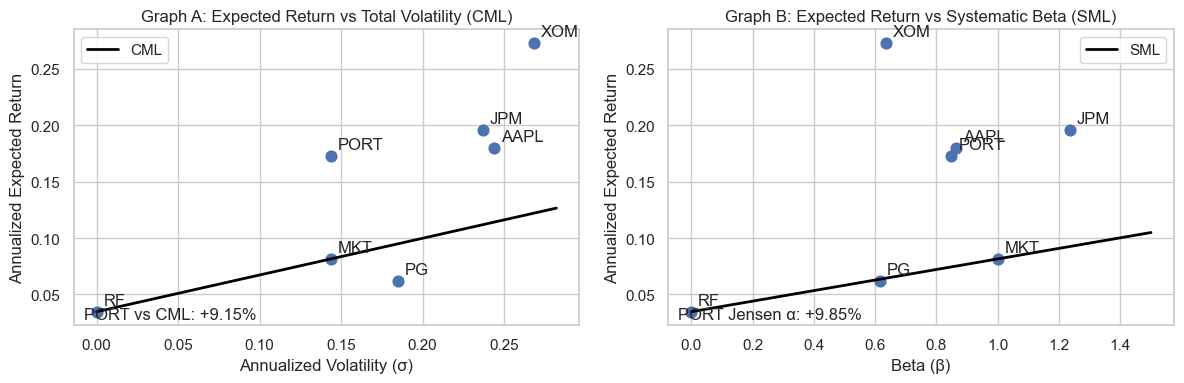

In [12]:
# Q3.4 — CML and SML visualizations (dual canvas)
plot_names = asset_tickers + ["PORT", "MKT", "RF"]
plot_df = perf.loc[plot_names].copy()

# CML line: E[R] = Rf + (E[Rm]-Rf)/sigma_m * sigma
sigma_max = float(plot_df["Sigma_ann"].max())
sigma_grid = np.linspace(0, sigma_max * 1.05, 200)
cml_slope = (rm_ann - rf_ann) / sigma_m_ann
cml_y = rf_ann + cml_slope * sigma_grid

# SML line: E[R] = Rf + beta*(E[Rm]-Rf)
beta_max = float(plot_df["Beta"].max())
beta_grid = np.linspace(0, max(1.5, beta_max * 1.1), 200)
sml_y = rf_ann + beta_grid * (rm_ann - rf_ann)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Graph A — CML
ax1.plot(sigma_grid, cml_y, color="black", lw=2, label="CML")
ax1.scatter(plot_df["Sigma_ann"], plot_df["R_ann"], s=60)
for name, row in plot_df.iterrows():
    ax1.annotate(name, (row["Sigma_ann"], row["R_ann"]), textcoords="offset points", xytext=(5, 5))
ax1.set_title("Graph A: Expected Return vs Total Volatility (CML)")
ax1.set_xlabel("Annualized Volatility (σ)")
ax1.set_ylabel("Annualized Expected Return")
ax1.legend(loc="best")

# Mark portfolio relative to CML
port_cml_gap = float(plot_df.loc["PORT", "R_ann"] - (rf_ann + cml_slope * plot_df.loc["PORT", "Sigma_ann"]))
ax1.text(0.02, 0.02, f"PORT vs CML: {port_cml_gap:+.2%}", transform=ax1.transAxes)

# Graph B — SML
ax2.plot(beta_grid, sml_y, color="black", lw=2, label="SML")
ax2.scatter(plot_df["Beta"], plot_df["R_ann"], s=60)
for name, row in plot_df.iterrows():
    ax2.annotate(name, (row["Beta"], row["R_ann"]), textcoords="offset points", xytext=(5, 5))
ax2.set_title("Graph B: Expected Return vs Systematic Beta (SML)")
ax2.set_xlabel("Beta (β)")
ax2.set_ylabel("Annualized Expected Return")
ax2.legend(loc="best")

# Mark portfolio relative to SML (Jensen alpha)
port_sml_gap = float(perf.loc["PORT", "Jensen_Alpha"])
ax2.text(0.02, 0.02, f"PORT Jensen α: {port_sml_gap:+.2%}", transform=ax2.transAxes)

fig.tight_layout()
fig_path = OUTPUT_DIR / "cml_sml_dual.png"
fig.savefig(fig_path)
print("Saved:", fig_path)
plt.show()

## Q3.5 — Using Jensen’s alpha in practical rebalancing
A quant analyst can treat **positive Jensen’s alpha** ($\alpha>0$) as evidence that an asset has delivered returns above what CAPM would require for its beta exposure.
In an automated strategy, one common workflow is:
- Estimate rolling betas and rolling alphas (e.g., 24–36 months).
- Tilt weights upward for assets with persistently positive, statistically stable alphas, while controlling risk via beta/volatility constraints.
- Rebalance periodically (monthly/quarterly) and include transaction-cost and turnover limits so the alpha signal is not over-traded.